<a href="https://colab.research.google.com/github/sathishmtech01/research_aiml_llm/blob/fema_v1/Fema_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install scikit-learn joblib gradio

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
from google.colab import files

uploaded = files.upload()  # Upload synthetic_fmea_data.csv
df = pd.read_csv('synthetic_fmea_data.csv')
df.head()

Saving synthetic_fmea_data.csv to synthetic_fmea_data.csv


,process_function,requirements,failure_mode,effects,causes,severity,occurrence,detection,RPN,reduced_RPN,actions_recommended
0,Assembly,Strength,Misalignment,System failure,Tool wear,8,2,9,144,130,Preventive maintenance
1,Drilling,Precision,Misalignment,Reduced efficiency,Operator error,5,3,10,150,138,Inspection
2,Drilling,Precision,Deformation,Product rejection,Operator error,2,9,6,108,102,Supplier change
3,Drilling,Compliance,Wear,Safety hazard,Operator error,9,9,2,162,117,Preventive maintenance
4,Assembly,Compliance,Deformation,Reduced efficiency,Improper setup,1,7,8,56,10,Inspection


In [5]:
df.shape

(100, 11)

In [3]:
text_features = ['process_function', 'requirements', 'failure_mode', 'effects', 'causes']
numeric_features = ['severity', 'occurrence', 'detection', 'RPN']
output_col = 'reduced_RPN'
action_col = 'actions_recommended'

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
train_df.head(1)

,process_function,requirements,failure_mode,effects,causes,severity,occurrence,detection,RPN,reduced_RPN,actions_recommended
55,Cutting,Durability,Misalignment,Safety hazard,Material defect,2,8,9,144,122,Inspection


In [6]:
vectorizers = {col: TfidfVectorizer() for col in text_features}
for col in text_features:
    vectorizers[col].fit(train_df[col])

X_train_text = np.hstack([vectorizers[col].transform(train_df[col]).toarray() for col in text_features])
X_test_text = np.hstack([vectorizers[col].transform(test_df[col]).toarray() for col in text_features])

In [13]:
X_train_text[0]

array([0.        , 1.        , 0.        , 0.        , 0.        ,
       0.        , 1.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 1.        , 0.        ,
       0.        , 0.        , 0.70710678, 0.        , 0.        ,
       0.        , 0.        , 0.70710678, 0.        , 0.70710678,
       0.        , 0.        , 0.        , 0.70710678, 0.        ,
       0.        , 0.        , 0.        ])

In [11]:
X_train_num = train_df[numeric_features].values
X_test_num = test_df[numeric_features].values

X_train = np.hstack([X_train_text, X_train_num])
X_test = np.hstack([X_test_text, X_test_num])

y_train = train_df[output_col].values
y_test = test_df[output_col].values

In [12]:
X_train_num[0]

array([  2,   8,   9, 144])

In [14]:
X_train[0]

array([  0.        ,   1.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   1.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   1.        ,   0.        ,   0.        ,
         0.        ,   0.70710678,   0.        ,   0.        ,
         0.        ,   0.        ,   0.70710678,   0.        ,
         0.70710678,   0.        ,   0.        ,   0.        ,
         0.70710678,   0.        ,   0.        ,   0.        ,
         0.        ,   2.        ,   8.        ,   9.        ,
       144.        ])

In [15]:
y_train[0]

np.int64(122)

In [16]:
from sklearn.tree import DecisionTreeRegressor
rfr = DecisionTreeRegressor(random_state=42)
rfr.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [20]:
#!pip install dtreeviz

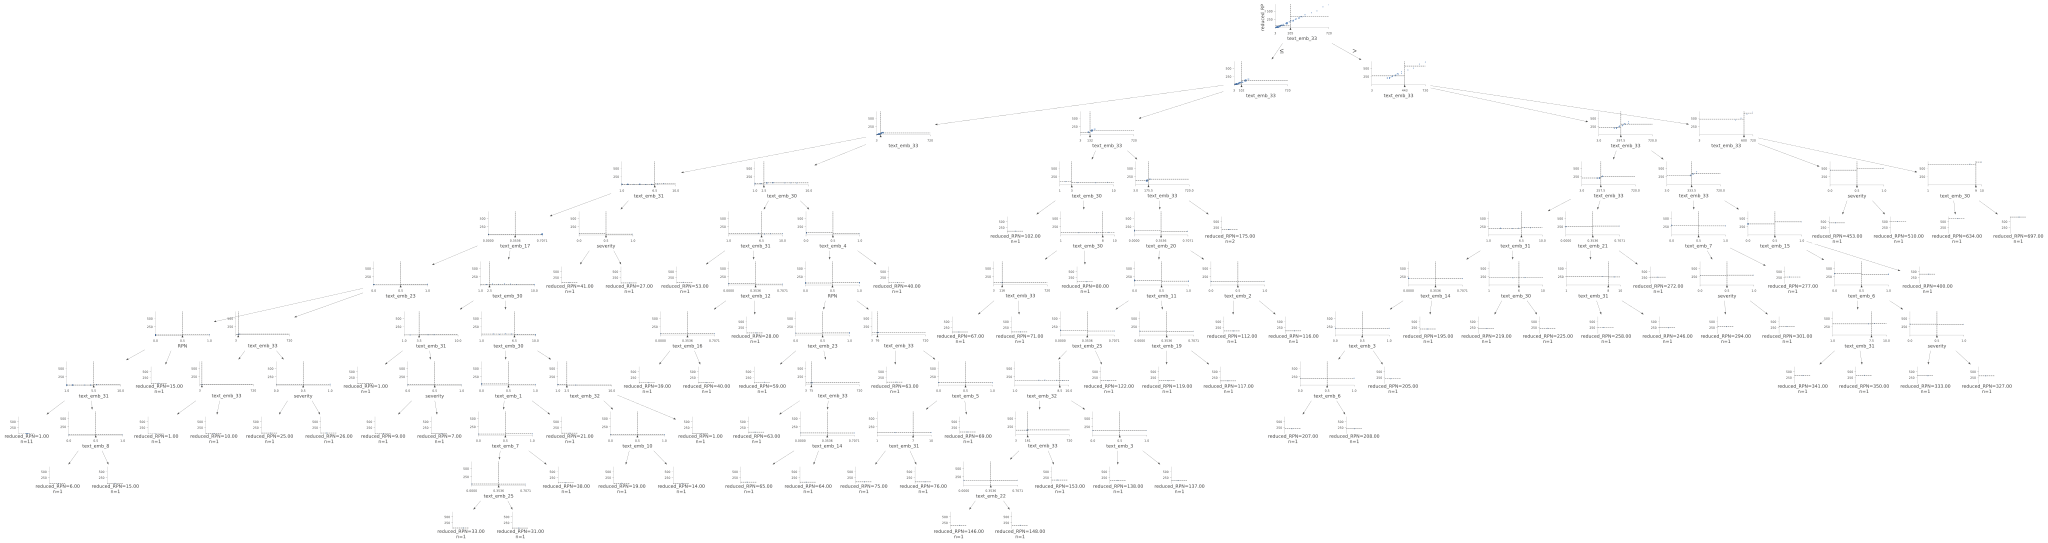

In [23]:
from dtreeviz import model
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

feature_names = numeric_features + [f"text_emb_{i+1}" for i in range(X_train_text.shape[1])]

viz_model = model(
    rfr,
    X_train,
    y_train,
    feature_names=feature_names,
    target_name=output_col
)
viz_model.view()

In [24]:
combo_text_train = train_df.apply(lambda row: ' '.join([str(row[c]) for c in text_features + numeric_features]), axis=1)
action_vectorizer = TfidfVectorizer()
action_vectors_train = action_vectorizer.fit_transform(combo_text_train)

In [25]:
joblib.dump(rfr, 'fmea_regressor.pkl')
joblib.dump(vectorizers, 'fmea_text_vectorizers.pkl')
joblib.dump(action_vectorizer, 'fmea_action_vectorizer.pkl')
joblib.dump(action_vectors_train, 'fmea_action_vectors_train.pkl')
train_df[action_col].to_csv('fmea_action_train_labels.csv', index=False)

print("✅ Model and vectorizers saved!")

✅ Model and vectorizers saved!


In [29]:
print("\nTesting on 5 samples...\n")
y_train_actions = pd.read_csv('fmea_action_train_labels.csv')[action_col]

for i in range(5):
    row = test_df.iloc[i]
    text_vec = np.hstack([vectorizers[col].transform([row[col]]).toarray() for col in text_features])
    numeric_vec = row[numeric_features].values.reshape(1, -1)
    full_vec = np.hstack([text_vec, numeric_vec])
    reduced_pred = rfr.predict(full_vec)[0]

    combo = ' '.join([str(row[c]) for c in text_features + numeric_features])
    input_vec = action_vectorizer.transform([combo])
    cos_sim = cosine_similarity(input_vec, action_vectors_train)
    best_idx = np.argmax(cos_sim)
    best_action = y_train_actions.iloc[best_idx]

    print(f"Actual reduced_RPN: {row[output_col]}, Predicted: {reduced_pred:.1f}")
    print(f"Actual action: {row[action_col]}")
    print(f"Predicted action: {best_action}\n---")

print("MAE:", mean_absolute_error(y_test, rfr.predict(X_test)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rfr.predict(X_test))))


Testing on 5 samples...

Actual reduced_RPN: 11, Predicted: 15.0
Actual action: Inspection
Predicted action: Preventive maintenance
---
Actual reduced_RPN: 87, Predicted: 67.0
Actual action: Inspection
Predicted action: Training
---
Actual reduced_RPN: 1, Predicted: 15.0
Actual action: Preventive maintenance
Predicted action: Supplier change
---
Actual reduced_RPN: 5, Predicted: 1.0
Actual action: Preventive maintenance
Predicted action: Training
---
Actual reduced_RPN: 57, Predicted: 40.0
Actual action: Supplier change
Predicted action: Inspection
---
MAE: 20.15
RMSE: 26.6392567463884


In [27]:
import gradio as gr

# Load everything
rfr = joblib.load('fmea_regressor.pkl')
vectorizers = joblib.load('fmea_text_vectorizers.pkl')
action_vectorizer = joblib.load('fmea_action_vectorizer.pkl')
action_vectors_train = joblib.load('fmea_action_vectors_train.pkl')
action_labels = pd.read_csv('fmea_action_train_labels.csv').values.flatten()

text_features = ['process_function', 'requirements', 'failure_mode', 'effects', 'causes']
numeric_features = ['severity', 'occurrence', 'detection', 'RPN']

# Choices (matching synthetic data generator options)
process_functions = [
    "Seal package", "Assemble part", "Apply label", "Inspect item", "Test circuit",
    "Deburr metal", "Paint surface", "Weld joint", "Calibrate sensor", "Pack box"
]
requirements = [
    "Seal 10 psi", "Tolerance 0.01mm", "Correct barcode", "No scratches", "Signal within 5V",
    "No sharp edges", "Finish matte", "Joint strength 100N", "Reading within 2%", "Weight <= 5kg"
]
failure_modes = [
    "Seal leaks", "Component misaligned", "Wrong label", "Surface scratch", "Signal out of range",
    "Sharp burr", "Paint chipped", "Weld crack", "Sensor drift", "Box not sealed"
]
effects = [
    "Leaks at customer", "Not usable", "Wrong product shipped", "Aesthetic issue", "Device inoperable",
    "User injury", "Poor appearance", "Structural risk", "Incorrect output", "Shipping damage"
]
causes = [
    "Too little pressure", "Human error", "Barcode mismatch", "Poor handling", "Component failure",
    "Dull tool", "Paint contamination", "Weld misalignment", "Sensor age", "Operator fatigue"
]

def predict(
    process_function, requirements, failure_mode, effects, causes,
    severity, occurrence, detection, RPN
):
    # Text vectors
    text_inputs = {
        'process_function': process_function,
        'requirements': requirements,
        'failure_mode': failure_mode,
        'effects': effects,
        'causes': causes
    }
    text_vec = np.hstack([vectorizers[col].transform([text_inputs[col]]).toarray() for col in text_features])
    numeric_vec = np.array([[severity, occurrence, detection, RPN]])
    full_vec = np.hstack([text_vec, numeric_vec])

    reduced_rpn_pred = rfr.predict(full_vec)[0]

    # Action recommendation
    combo = ' '.join([str(text_inputs[c]) for c in text_features] + [str(severity), str(occurrence), str(detection), str(RPN)])
    input_vec = action_vectorizer.transform([combo])
    cos_sim = cosine_similarity(input_vec, action_vectors_train)[0]

    best_idx = np.argmax(cos_sim)
    best_action = action_labels[best_idx]

    return round(reduced_rpn_pred, 2), best_action


iface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Dropdown(process_functions, label="Process Function"),
        gr.Dropdown(requirements, label="Requirements"),
        gr.Dropdown(failure_modes, label="Failure Mode"),
        gr.Dropdown(effects, label="Effects"),
        gr.Dropdown(causes, label="Causes"),
        gr.Slider(1, 10, value=5, step=1, label="Severity"),
        gr.Slider(1, 10, value=5, step=1, label="Occurrence"),
        gr.Slider(1, 10, value=5, step=1, label="Detection"),
        gr.Number(label="RPN")
    ],
    outputs=[
        gr.Number(label="Predicted Reduced RPN"),
        gr.Textbox(label="Recommended Action")
    ],
    title="FMEA Risk Mitigation Predictor",
    description="Predict the reduced RPN and suggest a recommended action."
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://583b51e2e95d089199.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
